<a href="https://colab.research.google.com/github/caoTayTang/image_super_resolution_traditional_cv/blob/main/notebooks/experiments_interpolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image

sys.path.append('..')
from modules.interpolation import sr_interpolation

In [13]:
img_path = '../data/target_lr/LR_x2/img_001_SRF_2_LR.png'

In [14]:
# LR 
img = Image.open(img_path)
arr = np.array(img)
h, w = arr.shape[:2]
lr_arr = cv2.resize(arr, (w//2, h//2), interpolation=cv2.INTER_CUBIC)
lr = Image.fromarray(lr_arr)

In [15]:
def show_img(img, title=""):
    plt.figure()
    dpi = 100  # dots per inch
    h, w = img.size
    plt.figure(figsize=(w/dpi, h/dpi), dpi=dpi)
    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.title(f"{title} {img.size}")
    plt.show()


<Figure size 640x480 with 0 Axes>

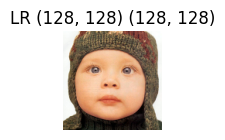

<Figure size 640x480 with 0 Axes>

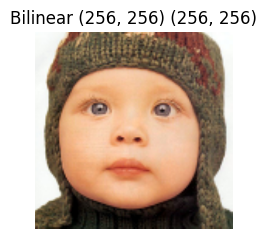

<Figure size 640x480 with 0 Axes>

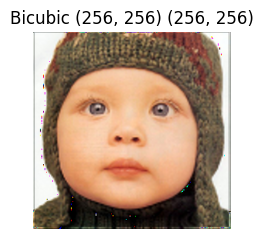

<Figure size 640x480 with 0 Axes>

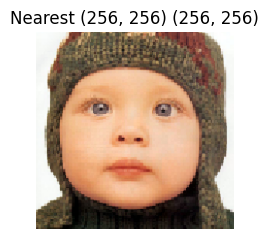

In [18]:


show_img(lr, f'LR {lr.size}')

sr_bilinear = sr_interpolation(lr, method="bilinear", scale=2)  # default
sr_bicubic = sr_interpolation(lr, method="bicubic", scale=2)  # default
sr_nearest = sr_interpolation(lr, method="nearest", scale=2)  # default
# sr_lanczos = sr_interpolation(lr, method="lanczos", scale=2)  # default
show_img(sr_bilinear, f'Bilinear {sr_bilinear.size}')
show_img(sr_bicubic, f'Bicubic {sr_bicubic.size}')
show_img(sr_nearest, f'Nearest {sr_nearest.size}')
# show_img(sr_lanczos, f'Lanczos {sr_lanczos.size}')


In [21]:
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline

np.random.seed(42)
grid_size = 5
values = np.random.rand(grid_size, grid_size)

x = np.linspace(0, grid_size - 1, grid_size)
y = np.linspace(0, grid_size - 1, grid_size)

x_fine = np.linspace(0, grid_size - 1, 500)
y_fine = np.linspace(0, grid_size - 1, 500)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

In [22]:
interp_nearest = RegularGridInterpolator((x, y), values, method='nearest')
z_nearest = interp_nearest((X_fine, Y_fine))

interp_bilinear = RegularGridInterpolator((x, y), values, method='linear')
z_bilinear = interp_bilinear((X_fine, Y_fine))

interp_bicubic = RectBivariateSpline(x, y, values, kx=3, ky=3)
z_bicubic = interp_bicubic(x_fine, y_fine)

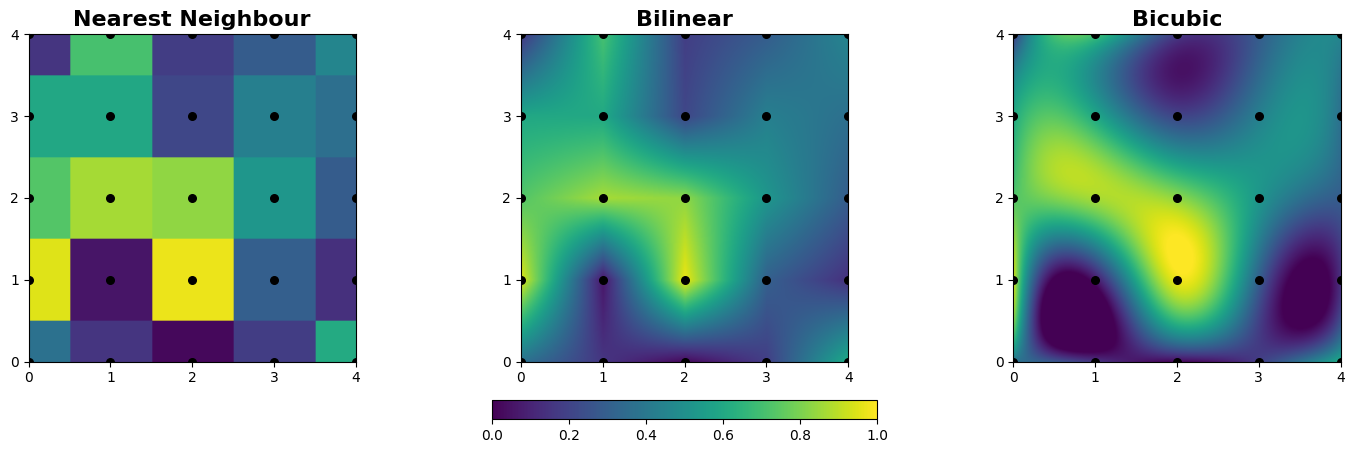

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Nearest Neighbour", "Bilinear", "Bicubic"]
results = [z_nearest, z_bilinear, z_bicubic]

for ax, tit, z_val in zip(axes, titles, results):
    im = ax.imshow(z_val.T, extent=[0, 4, 0, 4], origin='lower', cmap='viridis', vmin=0, vmax=1)
    X_orig, Y_orig = np.meshgrid(x, y)
    ax.scatter(X_orig, Y_orig, c='black', s=30, zorder=10) # s là kích thước chấm
    # Trang trí
    ax.set_title(tit, fontsize=16, fontweight='bold')
    ax.set_xticks(range(5))
    ax.set_yticks(range(5))
    ax.set_aspect('equal') # Giữ hình vuông
    
fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', fraction=0.05, pad=0.1)
plt.show()
